In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Utils

In [59]:
# font sizes
fig_width, fig_height = 12, 12/1.618
title_font_size = 18
y_label_font_size = 14
x_tick_font_size, y_tick_font_size = 15, 13
leg_title_font_size, leg_font_size = 14, 13
bar_label_font_size = 17
rotation = 0

# Function to add percentages (data labels) to the bars
def autolabel(ax, rects, percentages):
    for rect, percentage in zip(rects, percentages):
        if percentage > 0:
            height = rect.get_height()
            y_position = rect.get_y() + height / 2.0
            ax.text(
                rect.get_x() + rect.get_width() / 2., 
                y_position,
                f'{percentage:.1f}',
                ha='center', 
                va='center',
                fontsize=bar_label_font_size,
                color='black',
                rotation=rotation     # <--- rotate the label 90 degrees
            )

## Education level

./plots/education_within_females.png
./plots/education_within_males.png


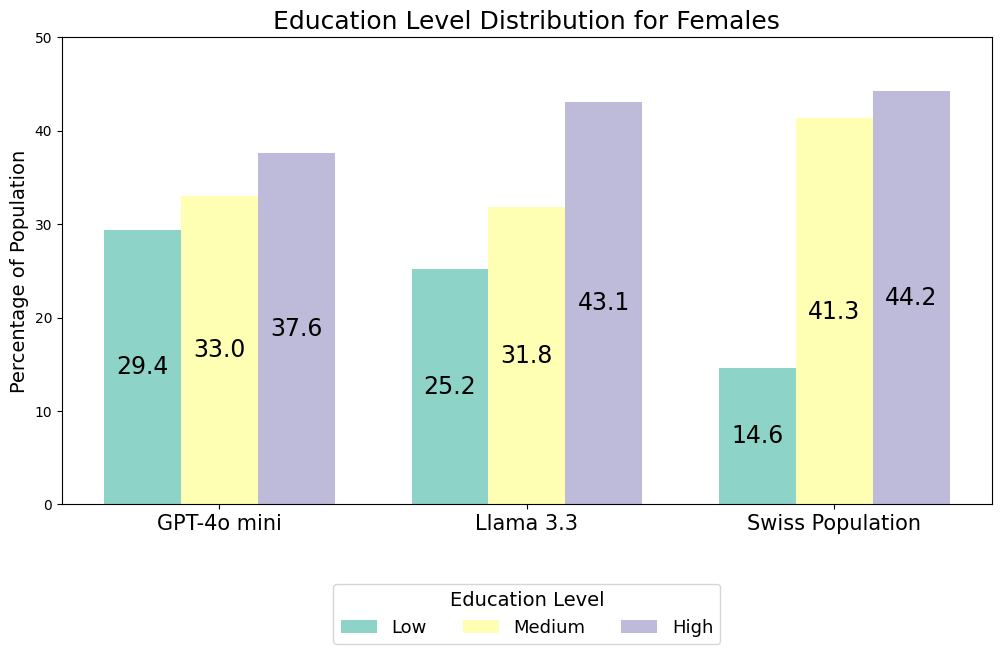

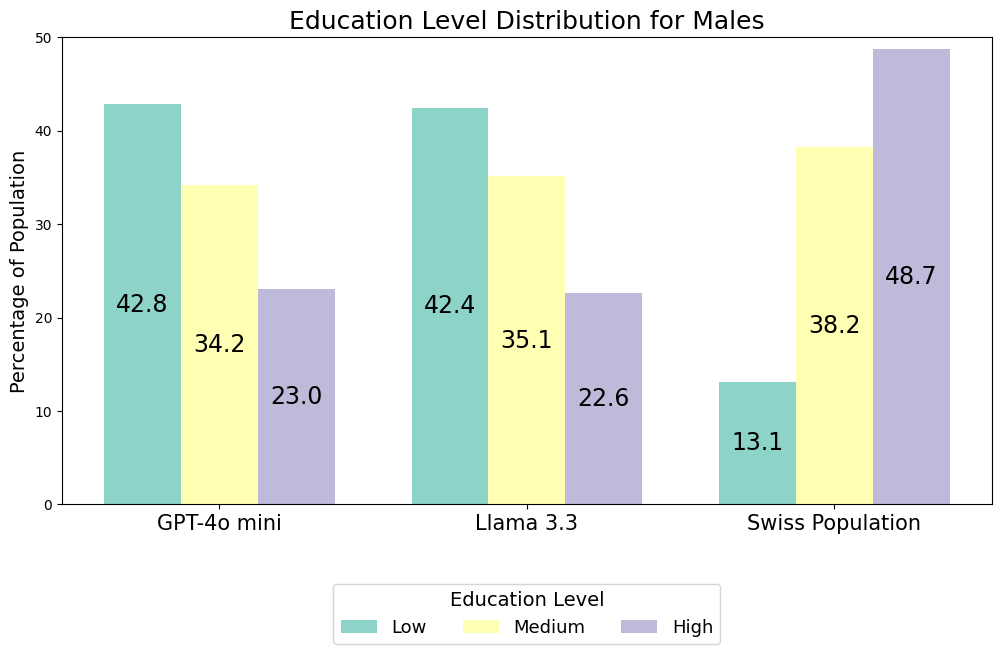

In [60]:
# TODO: read the data from some file

data = {
    'Model': ['GPT-4o mini', 'GPT-4o mini', 'Llama 3.3', 'Llama 3.3', 'Swiss Population', 'Swiss Population'],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    'Low': [42.8, 29.4, 42.4, 25.2, 13.1, 14.6],
    'Medium': [34.2, 33.0, 35.1, 31.8, 38.2, 41.3],
    'High': [23.0, 37.6, 22.6, 43.1, 48.7, 44.2]
}
df = pd.DataFrame(data)

# Filter dataframes for each gender
df_males = df[df['Gender'] == 'M'].reset_index(drop=True)
df_females = df[df['Gender'] == 'F'].reset_index(drop=True)

# Education levels order and colors
colors = ['#8dd3c7', '#ffffb3', '#bebada']
width = 0.5

# --- Generate the Stacked Bar Charts with Bottom Legend ---

def grouped_bars_edu(df_gender, gender_label, filename):
    labels = df_gender['Model'].tolist()
    low_vals = df_gender['Low'].values
    medium_vals = df_gender['Medium'].values
    high_vals = df_gender['High'].values

    x = np.arange(len(labels))
    width = 0.25   # width of each bar

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Plot grouped bars
    rects_low = ax.bar(x - width, low_vals, width, label='Low', color=colors[0])
    rects_medium = ax.bar(x, medium_vals, width, label='Medium', color=colors[1])
    rects_high = ax.bar(x + width, high_vals, width, label='High', color=colors[2])

    # Add numeric labels
    autolabel(ax, rects_low, low_vals)
    autolabel(ax, rects_medium, medium_vals)
    autolabel(ax, rects_high, high_vals)

    # Customize the chart
    ax.set_ylabel('Percentage of Population', fontsize=y_label_font_size)
    ax.set_title(f'Education Level Distribution for {gender_label}', fontsize=title_font_size)
    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=x_tick_font_size)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 50)
    
    ax.legend(
        title='Education Level',
        title_fontsize=leg_title_font_size,
        fontsize=leg_font_size,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3
    )

    plt.subplots_adjust(bottom=0.25) # Adjust subplot to make space for the legend
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    return filename

# Create and save both charts
female_chart_filename = grouped_bars_edu(df_females, 'Females', './plots/education_within_females.png')
male_chart_filename = grouped_bars_edu(df_males, 'Males', './plots/education_within_males.png')

print(f"{female_chart_filename}")
print(f"{male_chart_filename}")

## Marital status

./plots/marital_within_females.png
./plots/marital_within_males.png


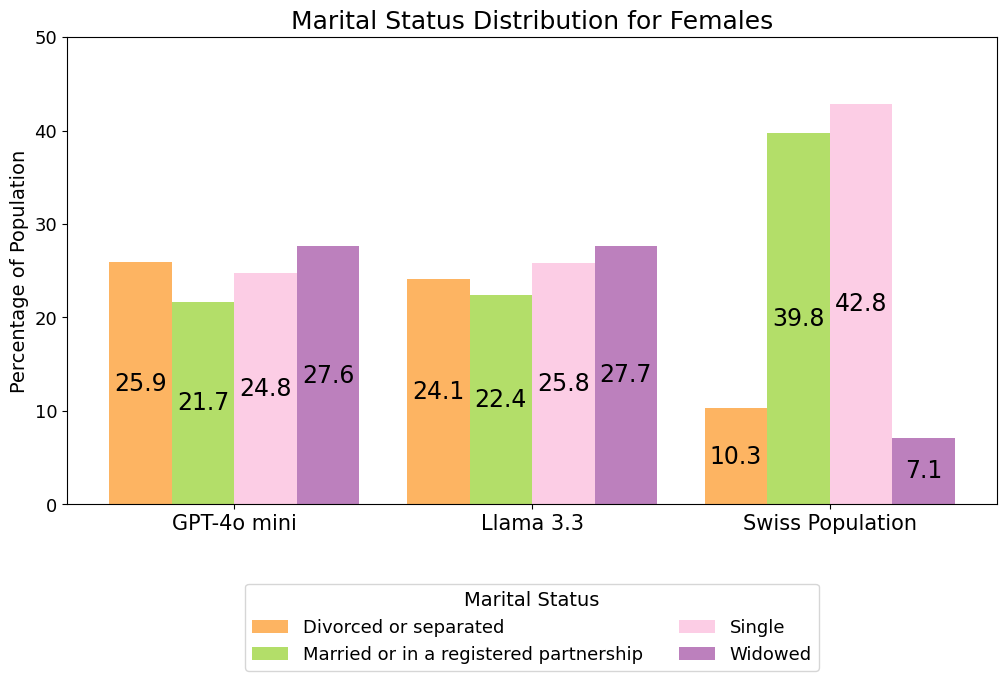

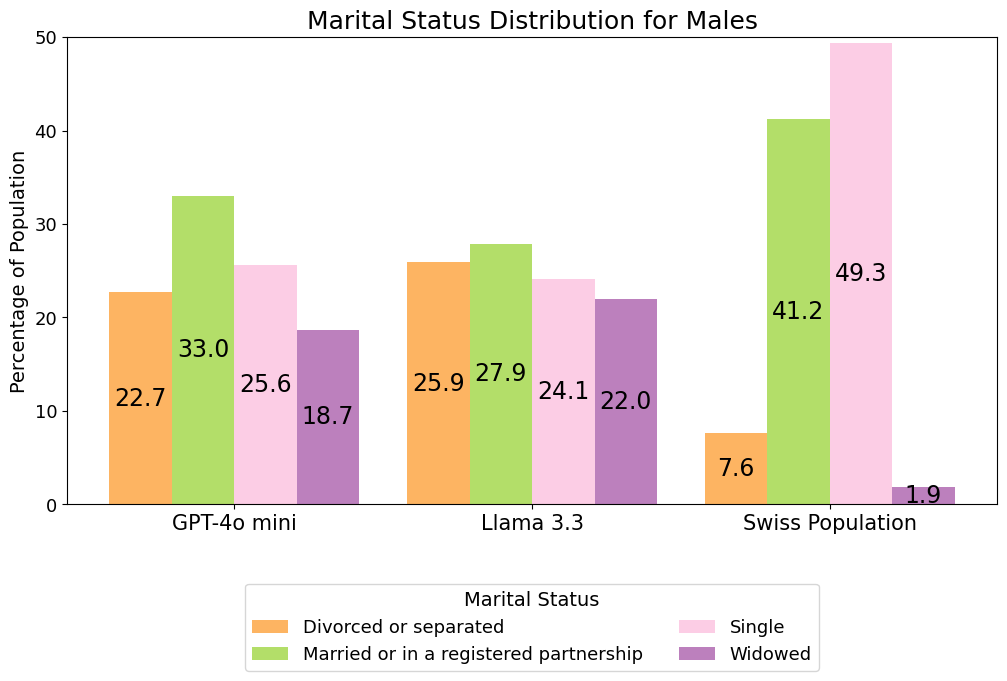

In [61]:
# TODO: read the data from some file

data_marital = {
    'Model': ['GPT-4o mini', 'GPT-4o mini', 'Llama 3.3', 'Llama 3.3', 'Swiss Population', 'Swiss Population'],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F'],
    'Divorced or separated': [22.7, 25.9, 25.9, 24.1, 7.61, 10.27],
    'Married or in a registered partnership': [33.0, 21.7, 27.9, 22.4, 41.20, 39.76],
    'Single': [25.6, 24.8, 24.1, 25.8, 49.33, 42.83],
    'Widowed': [18.7, 27.6, 22.0, 27.7, 1.85, 7.12]
}
df_marital = pd.DataFrame(data_marital)

# Filter dataframes for each gender
df_males_marital = df_marital[df_marital['Gender'] == 'M'].reset_index(drop=True)
df_females_marital = df_marital[df_marital['Gender'] == 'F'].reset_index(drop=True)

# Marital status categories and colors (4 categories, new color scheme)
marital_categories = ['Divorced or separated', 'Married or in a registered partnership', 'Single', 'Widowed']
colors_marital = ['#fdb462', '#b3de69', '#fccde5', '#bc80bd'] # New colorblind-safe palette
width = 0.5

# --- 2. Generate the Stacked Bar Charts for Marital Status ---

def grouped_bars_marital(df_gender, gender_label, filename):
    labels = df_gender['Model'].tolist()

    # Extract category values
    divorced_vals = df_gender[marital_categories[0]].values
    married_vals  = df_gender[marital_categories[1]].values
    single_vals   = df_gender[marital_categories[2]].values
    widowed_vals  = df_gender[marital_categories[3]].values

    # X positions
    x = np.arange(len(labels))
    width = 0.21

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Grouped bars with x-offsets
    rects_divorced = ax.bar(x - 1.5*width, divorced_vals, width,
                            label=marital_categories[0], color=colors_marital[0])

    rects_married = ax.bar(x - 0.5*width, married_vals, width,
                           label=marital_categories[1], color=colors_marital[1])

    rects_single = ax.bar(x + 0.5*width, single_vals, width,
                          label=marital_categories[2], color=colors_marital[2])

    rects_widowed = ax.bar(x + 1.5*width, widowed_vals, width,
                           label=marital_categories[3], color=colors_marital[3])

    # Labels on bars
    autolabel(ax, rects_divorced, divorced_vals)
    autolabel(ax, rects_married, married_vals)
    autolabel(ax, rects_single, single_vals)
    autolabel(ax, rects_widowed, widowed_vals)

    # --- FONT SIZES ---
    ax.set_ylabel('Percentage of Population', fontsize=y_label_font_size)
    ax.set_title(f'Marital Status Distribution for {gender_label}', fontsize=title_font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.tick_params(axis='x', labelsize=x_tick_font_size)
    ax.tick_params(axis='y', labelsize=y_tick_font_size)

    ax.set_ylim(0, 50)
    
    # Legend (2 columns × 2 rows)
    ax.legend(
        title='Marital Status',
        title_fontsize=leg_title_font_size,
        fontsize=leg_font_size,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=2
    )

    plt.subplots_adjust(bottom=0.25)
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    return filename

# Create and save both charts
female_chart_filename = grouped_bars_marital(df_females_marital, 'Females', './plots/marital_within_females.png')
male_chart_filename = grouped_bars_marital(df_males_marital, 'Males', './plots/marital_within_males.png')

print(f"{female_chart_filename}")
print(f"{male_chart_filename}")

## Occupation